# FIP 08 — DA, NE and movement

How do DA and NE relate to movement, does their RPE coding relate to movement, what movement goes
with DA and NE events, and how are instructed and uninstructed movements represented?

Movement is motion energy (ME) from the bottom camera: the summed absolute frame-to-frame pixel
change, from the aligned ME table (`fip_motion_energy_aligned`, frame times corrected by the video
timing QC). Cameras that fail the video timing or quality screen are left out. `men_00` describes
ME against the task and checks its clock (lick-triggered ME peaks within 0.07 s of the lick in every
session).

DA is dLight in lateral NAc. NE is GCaMP in LC noradrenergic axons imaged in PL (axonal calcium).
The two indicators have different kinetics, so lags between signals are not read as timing.

**Data and conventions.** The same-hemisphere DA/NE sessions of `fip_05`/`fip_07` (CSV-curated
assets, one side per animal) that have bottom-camera ME. DA, NE and ME are on one 20 Hz grid (ME
averaged within each bin), each z-scored over the session. Session means are averaged within
animal; tests are Wilcoxon signed-rank on animal means.

0b. Cross-correlation and coherence of each pair: DA–NE, DA–ME, NE–ME
1. DA and NE at movement onsets; cross-correlation with ME; variance explained by the task and by ME
2. The DA–NE correlation with task and movement removed
3. RPE coding of DA, NE and ME; DA and NE RPE terms with ME as a covariate
4. ME around large DA and NE transients, with and without a partner in the other signal
5. DA, NE and ME at instructed lick bouts, uninstructed lick bouts and movements without licking

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import signal_utils as su
import stats_utils as st
import behavior_utils as bu
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
PAIRS_CACHE = ("/root/capsule/scratch/fip_05/pairs.pkl" if IS_CO
               else "../../data/fip_05_cache/pairs.pkl")
FIG_DIR = "/root/capsule/scratch/figures/fip" if IS_CO else "../data/figures/fip"
SAVE_FIG = True

# ── Data ─────────────────────────────────────────────────────────────────────
FS = 20.0                  # Hz, the common grid
FS_ONSET = 100.0           # Hz, ME onsets are detected at men_00's rate
CAMERA = "BottomCamera"
MIN_SESSIONS_PER_ANIMAL = 3
EXCLUDE_SUBJECTS = ()      # QC decides; none excluded

# ── 0b. Pairwise coupling (fip_07 Fig 1 for DA–NE, DA–ME, NE–ME) ─────────────
PAIRS = [("ne", "da"), ("da", "me"), ("ne", "me")]   # (a, b): + lag = a later than b
COH_NPERSEG = 1024         # 51.2-s Welch segments
COH_BAND_HZ = (0.02, 2.0)  # coherence band tested (fip_07's)
# coherence by band, separate figure: slow/state, trial rate (~0.15 Hz), within trial. The first band
# starts at the first non-zero Welch bin (1 / 51.2 s ≈ 0.0195 Hz); bins are [lo, hi).
COH_BANDS = {"0.02–0.1 Hz": (1 / 51.2, 0.1), "0.1–0.5 Hz": (0.1, 0.5), "0.5–2 Hz": (0.5, 2.0)}
EXAMPLE_SESSION = "800886_2025-09-03"   # fip_07 Fig 1's example; None = median DA–NE peak r
EXAMPLE_WINDOW_S, EXAMPLE_ZOOM_S = 180.0, 20.0

# ── 1. Movement ──────────────────────────────────────────────────────────────
ETA_LAGS = np.arange(-2.0, 3.0 + 1e-9, 1 / FS)   # around events
MAXLAG_S = 3.0             # cross-correlation lags
N_SHIFT = 200              # circular shifts for the cross-correlation null
MIN_SHIFT_S = 60.0         # smallest circular shift
KERNEL_S = (-1.0, 4.0)     # task-event kernels (fip_05's task model)
ME_LAGS_S = (-1.0, 2.0)    # ME regressors: the signal may follow ME by up to 2 s, or lead it by 1 s
N_SHIFT_R2 = 10            # circular shifts of ME for the variance-explained null

# ── 3. RPE ───────────────────────────────────────────────────────────────────
OUTCOME_WIN = (0.0, 2.0)   # s after the outcome
BASELINE = (-1.0, 0.0)     # s around the go cue, subtracted from the outcome response
RPE_COVARIATES = ["response_time", "trial_frac"]   # as fip_05
MIN_RPE_SD = 0.05          # sessions with flatter within-outcome RPE are left out (fip_05)

# ── 4. Transients (fip_07 Fig 2) ─────────────────────────────────────────────
LARGE_PROM, PARTNER_PROM, MATCH_WIN_S, MIN_SEP_S = 2.0, 1.0, 0.5, 0.5
PEAK_WIN = (-0.5, 0.5)     # ME window around the transient peak

# ── 5. Movement types (men_00 definitions) ───────────────────────────────────
INSTRUCTED_S = 2.0         # lick bouts starting ≤ 2 s after a go cue are instructed
LICK_WIN = (-0.5, 1.0)     # an ME event has licking if a lick falls in [onset − 0.5, onset + 1] s
PRE_WIN = (-1.0, -0.2)     # response = mean over RESP_WIN minus mean over PRE_WIN
RESP_WIN = (0.0, 1.0)

# ── Colors ───────────────────────────────────────────────────────────────────
SIG = ("da", "ne", "me")
SIG_COLOR = {"da": OKABE_ITO["vermillion"], "ne": OKABE_ITO["blue"], "me": "0.25"}
SIG_LABEL = {"da": "DA (NAc dLight)", "ne": "NE (PL LC-axon GCaMP)", "me": "ME (bottom camera)"}
OUT_COLOR = {"rewarded": OKABE_ITO["orange"], "unrewarded": "0.55"}
NULL_COLOR = PALETTE["not_sig"]
TYPE_COLOR = {"instructed, rewarded": OKABE_ITO["orange"], "instructed, unrewarded": "0.55",
              "uninstructed lick bout": OKABE_ITO["bluish_green"],
              "movement, no lick": OKABE_ITO["reddish_purple"]}
PAIR_KEY = {pr: f"{pr[0]}_{pr[1]}" for pr in PAIRS}
PAIR_LABEL = {("ne", "da"): "DA–NE", ("da", "me"): "DA–ME", ("ne", "me"): "NE–ME"}
PAIR_COLOR = {("ne", "da"): OKABE_ITO["reddish_purple"], ("da", "me"): OKABE_ITO["vermillion"],
              ("ne", "me"): OKABE_ITO["blue"]}
rng = np.random.default_rng(0)

## 0. Data

Pairs are loaded as in `fip_05`/`fip_07` (`fu.load_pairs`, cached). For each session with a usable
bottom camera, ME on the session clock (`fu.motion_energy_to_session`) is averaged onto the pair's
20 Hz grid and onto a 100 Hz grid for onset detection. ME onsets: `fu.ME_ONSET_KW` (2.5 SD for
30 ms, one per 0.5 s) on the z-scored 100 Hz trace, inside the grid.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    print(f"{name}: {root}")
    if root:
        asset_roots[name] = root

inv = fu.inventory_pairs(asset_roots)
kept, side_table = fu.choose_side(inv, MIN_SESSIONS_PER_ANIMAL)
all_pairs = fu.load_pairs(kept, fs=FS, cache_path=PAIRS_CACHE)
path_of = dict(zip(kept["session"], kept["path"]))
me_ok = set(fu.me_sessions(CAMERA, data_root=ME_DATA_ROOT))

pairs = []
for p in all_pairs:
    if p["session"] not in me_ok or p["subject"] in EXCLUDE_SUBJECTS:
        continue
    path = path_of[p["session"]]
    trials_raw = pd.read_parquet(os.path.join(path, "df_trials.parquet"))
    t_me, y, _ = fu.motion_energy_to_session(p["session"], trials_raw, camera=CAMERA,
                                             data_root=ME_DATA_ROOT)
    n = len(p["da"])
    n100 = int(n * FS_ONSET / FS)
    me100 = su.zscore(su.bin_to_grid(t_me, y, p["t0"], FS_ONSET, n100))
    onsets = su.threshold_onsets(p["t0"] + np.arange(n100) / FS_ONSET, me100, already_z=True,
                                 **fu.ME_ONSET_KW)
    events = pd.read_parquet(os.path.join(path, "df_events.parquet"), columns=["timestamps", "event"])
    q = dict(p)
    q["z"] = {"da": su.zscore(p["da"]), "ne": su.zscore(p["ne"]),
              "me": np.nan_to_num(su.zscore(su.bin_to_grid(t_me, y, p["t0"], FS, n)))}
    q["me_onsets"] = onsets
    q["lick_events"] = events[events["event"].isin(["left_lick_time", "right_lick_time"])]
    pairs.append(q)

SUBJECTS = sorted({p["subject"] for p in pairs})
PAIR_SUBJECTS = [p["subject"] for p in pairs]
N_ANIMALS = len(SUBJECTS)
print(f"{len(pairs)} of {len(all_pairs)} sessions have bottom-camera ME; {N_ANIMALS} animals")
pd.Series(PAIR_SUBJECTS).value_counts().sort_index().rename("sessions").to_frame().T

3ch: ../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f
4ch: ../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1/data


loaded 97 pairs from cache ../../data/fip_05_cache/pairs.pkl


88 of 97 sessions have bottom-camera ME; 9 animals


,800886,808054,809487,809491,815334,816212,816214,818585,818586
sessions,4,15,8,19,3,5,5,7,22


In [4]:
def animal_traces(per_session):
    # [(subject, trace)] -> (n_animals, n_lags): session traces averaged within animal
    if not per_session:
        return np.empty((0, len(ETA_LAGS)))
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]


def report(title, df, cols):
    # mean ± SEM over animals and Wilcoxon p against zero, one row per column of an animal table
    rows = []
    for c in cols:
        m, p, n = st.wilcoxon_animals(df[c])
        rows.append(dict(measure=c, mean=m, sem=df[c].std(ddof=1) / np.sqrt(df[c].notna().sum()),
                         p=p, n=n))
    print(f"── {title}")
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()

## 0b. DA, NE and ME: cross-correlation and coherence of each pair

`fip_07` Figure 1, run for all three pairs on the sessions here. Per session and pair: the
normalized cross-correlation within ±3 s (`su.xcorr_shift_null(a, b)`: + lag = *a* later) and
magnitude-squared coherence (Welch, 51.2-s segments), each against 200 circular shifts of *b* by at
least 60 s. Lag signs: DA–NE + = NE later; DA–ME + = DA later; NE–ME + = NE later.

- **Peak r**: the largest |r| within ±3 s, with its sign, and its lag. Effect = peak |r| minus the
  null's median peak |r|.
- **Coherence**: mean over 0.02–2 Hz (`fip_07`'s band) minus the same mean for the shift-null median.
  DA and NE carry little power above 2 Hz; ME carries more, so any ME coupling above 2 Hz is outside
  this measure.
- Pairs are compared with Wilcoxon signed-rank on the per-animal differences.
- A further figure splits coherence into three bands (`COH_BANDS`): 0.02–0.1 Hz (slow, state-like),
  0.1–0.5 Hz (around the trial rate) and 0.5–2 Hz (within trial), each against its own shift null.
  The single 0.02–2 Hz mean is dominated by its 0.2–2 Hz bins, because Welch bins are evenly spaced in Hz.


In [ ]:
K_LAG = int(round(MAXLAG_S * FS))
LAGS = np.arange(-K_LAG, K_LAG + 1) / FS
MEASURES = ["peak_r", "peak_lag", "r0", "peak_r_effect", "coh_band", "coh_effect"]

pair_rows = []
pair_curves = {pr: dict(xc=[], xc_null=[], coh=[], coh_null=[]) for pr in PAIRS}
for p in pairs:
    z = p["z"]
    for a, b in PAIRS:
        _, cc, null = su.xcorr_shift_null(z[a], z[b], FS, MAXLAG_S, N_SHIFT, MIN_SHIFT_S, rng)
        f_coh, coh, coh_null = su.coherence_shift_null(z[a], z[b], FS, COH_NPERSEG, N_SHIFT,
                                                       MIN_SHIFT_S, rng)
        in_band = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])
        k = int(np.argmax(np.abs(cc)))
        null_peaks = np.abs(null).max(1)
        band_obs, band_null = coh[in_band].mean(), coh_null[:, in_band].mean(1)
        c = pair_curves[(a, b)]
        c["xc"].append(cc)
        c["xc_null"].append(np.percentile(null, [2.5, 97.5], axis=0))
        c["coh"].append(coh)
        c["coh_null"].append(np.percentile(coh_null, 95, axis=0))
        pair_rows.append(dict(subject=p["subject"], session=p["session"], pair=PAIR_KEY[(a, b)],
                              peak_r=cc[k], peak_lag=LAGS[k], r0=cc[K_LAG],
                              peak_r_effect=abs(cc[k]) - np.median(null_peaks),
                              null_peak_95=np.percentile(null_peaks, 95),
                              p_xc=st.shift_p(abs(cc[k]), null_peaks),
                              coh_band=band_obs, coh_effect=band_obs - np.median(band_null),
                              p_coh=st.shift_p(band_obs, band_null)))
        for name, (lo, hi) in COH_BANDS.items():   # band split, for the band figure
            m = (f_coh >= lo - 1e-9) & (f_coh < hi)
            b_obs, b_null = coh[m].mean(), coh_null[:, m].mean(1)
            pair_rows[-1].update({f"coh[{name}]": b_obs, f"coh_effect[{name}]": b_obs - np.median(b_null),
                                  f"p_coh[{name}]": st.shift_p(b_obs, b_null)})
pair_sess = pd.DataFrame(pair_rows)
IN_F = (f_coh >= COH_BAND_HZ[0]) & (f_coh <= COH_BAND_HZ[1])

# one row per session, one column per measure × pair, then animal means
wide = pair_sess.pivot_table(index=["subject", "session"], columns="pair", values=MEASURES)
wide.columns = [f"{m}_{pk}" for m, pk in wide.columns]
pair_animal = st.animal_means(wide.reset_index(), list(wide.columns), by_session=False)

# animal-mean curves per pair
pair_xc = {pr: st.group_means(c["xc"], PAIR_SUBJECTS)[1] for pr, c in pair_curves.items()}
pair_coh = {pr: st.group_means(c["coh"], PAIR_SUBJECTS)[1] for pr, c in pair_curves.items()}
pair_xc_null = {pr: st.group_means(c["xc_null"], PAIR_SUBJECTS)[1].mean(0) for pr, c in pair_curves.items()}
pair_coh_null = {pr: st.group_means(c["coh_null"], PAIR_SUBJECTS)[1].mean(0) for pr, c in pair_curves.items()}

sig_frac = pair_sess.groupby("pair")[["p_xc", "p_coh"]].agg(lambda v: (v < 0.05).mean())
print("fraction of sessions above their shift null (p < 0.05)\n", sig_frac.round(2), "\n")
for m in MEASURES:
    report(m, pair_animal, [f"{m}_{PAIR_KEY[pr]}" for pr in PAIRS])

# pair against pair, per animal
cmp_rows = []
for m in ("peak_r", "coh_effect"):
    for i, x in enumerate(PAIRS):
        for y in PAIRS[i + 1:]:
            d = pair_animal[f"{m}_{PAIR_KEY[x]}"] - pair_animal[f"{m}_{PAIR_KEY[y]}"]
            mean, pv, n = st.wilcoxon_animals(d)
            cmp_rows.append(dict(measure=m, comparison=f"{PAIR_LABEL[x]} − {PAIR_LABEL[y]}",
                                 mean_diff=mean, p=pv, animals_positive=f"{int((d > 0).sum())}/{n}"))
pair_cmp = pd.DataFrame(cmp_rows)
print("── pair against pair (Wilcoxon on animal differences)")
print(pair_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

In [ ]:
ex_names = [p["session"] for p in pairs]
dane = pair_sess[pair_sess.pair == PAIR_KEY[("ne", "da")]].reset_index(drop=True)
if EXAMPLE_SESSION in ex_names:
    ex_i = ex_names.index(EXAMPLE_SESSION)
else:
    ex_i = int(np.argmin(np.abs(dane.peak_r - dane.peak_r.median())))
ex = pairs[ex_i]
ex_rows = pair_sess[pair_sess.session == ex["session"]].set_index("pair")
ex_t = ex["t0"] + np.arange(len(ex["da"])) / FS   # session time of each grid sample
t_mid = 0.5 * (ex_t[0] + ex_t[-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_z = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)
CUE = "goCue_start_time_in_session"


def plot_event_ticks(ax, p, win, legend=False):
    tr = p["trials"]
    for col, sel, c, lab, yy in ((CUE, np.ones(len(tr), bool), PALETTE["neutral"], "go cue", 1.0),
                                 ("reward_outcome_time_in_session", tr["earned_reward"].astype(bool),
                                  OUT_COLOR["rewarded"], "reward", 0.94)):
        t = tr.loc[sel, col].dropna().to_numpy()
        t = t[(t >= win[0]) & (t < win[1])]
        ax.plot(t, np.full(len(t), yy), "|", color=c, ms=7, mew=1.2, label=lab,
                transform=ax.get_xaxis_transform(), clip_on=False)


def plot_example_traces(ax_top, ax_me, p, win, shade=None, legend=False):
    t = p["t0"] + np.arange(len(p["da"])) / FS
    m = (t >= win[0]) & (t < win[1])
    for s in ("da", "ne"):
        ax_top.plot(t[m], p["z"][s][m], color=SIG_COLOR[s], lw=1.0, label=SIG_LABEL[s])
    ax_me.plot(t[m], p["z"]["me"][m], color=SIG_COLOR["me"], lw=1.0, label=SIG_LABEL["me"])
    plot_event_ticks(ax_top, p, win)
    for ax in (ax_top, ax_me):
        if shade:
            ax.axvspan(*shade, color=NULL_COLOR, alpha=0.2, lw=0)
        ax.set_xlim(win)
        style_ax(ax)
    ax_top.set_ylabel("DA, NE (z)")
    ax_me.set_ylabel("ME (z)")
    ax_top.tick_params(labelbottom=False)
    ax_me.set_xlabel("time in session (s)")
    if legend:
        h = ax_top.get_legend_handles_labels()
        h2 = ax_me.get_legend_handles_labels()
        ax_top.legend(h[0] + h2[0], h[1] + h2[1], loc="lower right", bbox_to_anchor=(1.0, 1.06),
                      ncol=5, frameon=False, fontsize=8)


fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 0.6, 1.3], hspace=0.25, wspace=0.28, top=0.9)
gs_bottom = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 0.6, 1.3], hspace=0.55, wspace=0.28, top=0.9)

ax = fig.add_subplot(gs[0, :2]); ax2 = fig.add_subplot(gs[1, :2], sharex=ax)
plot_example_traces(ax, ax2, ex, win_a, shade=win_z, legend=True)
ax.set_title(f"a   {EXAMPLE_WINDOW_S:.0f} s", loc="left", pad=24)
ax = fig.add_subplot(gs[0, 2]); ax2 = fig.add_subplot(gs[1, 2], sharex=ax)
plot_example_traces(ax, ax2, ex, win_z)
ax.set_title(f"b   zoom, {EXAMPLE_ZOOM_S:.0f} s", loc="left", pad=24)

ax = fig.add_subplot(gs_bottom[2, 0])
for pr in PAIRS:
    lo, hi = pair_curves[pr]["xc_null"][ex_i]
    ax.fill_between(LAGS, lo, hi, color=PAIR_COLOR[pr], alpha=0.12, lw=0)
    r = ex_rows.loc[PAIR_KEY[pr]]
    ax.plot(LAGS, pair_curves[pr]["xc"][ex_i], color=PAIR_COLOR[pr], lw=2,
            label=f"{PAIR_LABEL[pr]}: r = {r.peak_r:+.2f} at {r.peak_lag:+.2f} s")
    ax.plot(r.peak_lag, r.peak_r, "o", color=PAIR_COLOR[pr], ms=7)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (s); + = NE later (DA–NE, NE–ME), DA later (DA–ME)")
ax.set_ylabel("r")
ax.set_title("c   cross-correlation (bands: shift null 95%)", loc="left")
ax.set_ylim(top=1.5 * ex_rows["peak_r"].abs().max())   # headroom for the legend
ax.legend(fontsize=8, loc="upper left", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs_bottom[2, 1])
for pr in PAIRS:
    r = ex_rows.loc[PAIR_KEY[pr]]
    ax.semilogx(f_coh[IN_F], pair_curves[pr]["coh"][ex_i][IN_F], color=PAIR_COLOR[pr], lw=1.4,
                label=f"{PAIR_LABEL[pr]}: {r.coh_band:.2f} (null {r.coh_band - r.coh_effect:.2f})")
    ax.semilogx(f_coh[IN_F], pair_curves[pr]["coh_null"][ex_i][IN_F], color=PAIR_COLOR[pr], lw=1,
                ls="--", alpha=0.7)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title("d   coherence (dashed: shift null 95%)", loc="left")
ax.legend(fontsize=8, loc="upper right", frameon=False, title="mean 0.02–2 Hz", title_fontsize=8)
style_ax(ax)

ax = fig.add_subplot(gs_bottom[2, 2])
ax.axis("off")
cells = [[PAIR_LABEL[pr], f"{ex_rows.loc[PAIR_KEY[pr], 'peak_r']:+.2f}",
          f"{ex_rows.loc[PAIR_KEY[pr], 'peak_lag']:+.2f}", f"{ex_rows.loc[PAIR_KEY[pr], 'r0']:+.2f}",
          f"{ex_rows.loc[PAIR_KEY[pr], 'coh_effect']:.2f}"] for pr in PAIRS]
tbl = ax.table(cellText=cells, colLabels=["pair", "peak r", "lag (s)", "r at 0", "coh − null"],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)
for k, pr in enumerate(PAIRS):
    tbl[k + 1, 0].get_text().set_color(PAIR_COLOR[pr])
ax.set_title("e   this session", loc="left")

fig.suptitle(f"DA, NE and ME: one session ({ex['session']}, {ex['side']})", x=0.01, ha="left")
save_fig(fig, "fip_08_0b_pairs_example", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.9, top=0.9)

ax = fig.add_subplot(gs[0, :3])
lo = np.min([pair_xc_null[pr][0] for pr in PAIRS], 0)
hi = np.max([pair_xc_null[pr][1] for pr in PAIRS], 0)
ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
for pr in PAIRS:
    pu.plot_mean_sem(ax, LAGS, list(pair_xc[pr]), PAIR_COLOR[pr], PAIR_LABEL[pr])
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (s); + = NE later (DA–NE, NE–ME), DA later (DA–ME)")
ax.set_ylabel("r")
ax.set_title(f"a   cross-correlation, mean ± SEM over animals (n = {N_ANIMALS})", loc="left")
ax.legend(fontsize=8, loc="upper left", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs[0, 3:])
for pr in PAIRS:
    pu.plot_mean_sem(ax, f_coh[IN_F], pair_coh[pr][:, IN_F], PAIR_COLOR[pr], PAIR_LABEL[pr])
    ax.plot(f_coh[IN_F], pair_coh_null[pr][IN_F], color=PAIR_COLOR[pr], lw=1, ls="--", alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title("b   coherence, mean ± SEM over animals (dashed: shift null 95%)", loc="left")
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

labels = [PAIR_LABEL[pr] for pr in PAIRS]
colors = [PAIR_COLOR[pr] for pr in PAIRS]
for k, (m, ylab, title) in enumerate((("peak_r", "peak r", "c   peak r"),
                                      ("peak_lag", "peak lag (s)", "d   lag of the peak"),
                                      ("coh_effect", "coherence − shift null", "e   coherence 0.02–2 Hz"))):
    ax = fig.add_subplot(gs[1, 2 * k:2 * k + 2])
    pu.strip_by_measure(ax, pair_animal, [f"{m}_{PAIR_KEY[pr]}" for pr in PAIRS], labels, colors,
                        ylab, title)

fig.suptitle(f"DA, NE and ME: cross-correlation and coherence of each pair — {len(pairs)} sessions, "
             f"{N_ANIMALS} animals (points = animals; stars: Wilcoxon against 0)", x=0.01, ha="left")
save_fig(fig, "fip_08_0b_pairs_summary", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 0b, by band

Coherence of each pair in three bands, observed minus the shift-null median, one point per animal.
**a** the animal-mean coherence spectra with the bands marked; **b** the band profile of each pair
(mean ± SEM over animals); **c–e** one panel per band.

In [ ]:
BAND_NAMES = list(COH_BANDS)
band_cols = [f"coh_effect[{b}]" for b in BAND_NAMES]
band_wide = pair_sess.pivot_table(index=["subject", "session"], columns="pair", values=band_cols)
band_wide.columns = [f"{m}_{pk}" for m, pk in band_wide.columns]
band_animal = st.animal_means(band_wide.reset_index(), list(band_wide.columns), by_session=False)

print("fraction of sessions above their shift null (p < 0.05), by band")
print(pair_sess.groupby("pair")[[f"p_coh[{b}]" for b in BAND_NAMES]].agg(lambda v: (v < 0.05).mean()).round(2), "\n")
for b in BAND_NAMES:
    report(f"coherence − null, {b}", band_animal, [f"coh_effect[{b}]_{PAIR_KEY[pr]}" for pr in PAIRS])
cmp_rows = []
for b in BAND_NAMES:
    for i, x in enumerate(PAIRS):
        for y in PAIRS[i + 1:]:
            d = band_animal[f"coh_effect[{b}]_{PAIR_KEY[x]}"] - band_animal[f"coh_effect[{b}]_{PAIR_KEY[y]}"]
            mean, pv, n = st.wilcoxon_animals(d)
            cmp_rows.append(dict(band=b, comparison=f"{PAIR_LABEL[x]} − {PAIR_LABEL[y]}", mean_diff=mean, p=pv,
                                 animals_positive=f"{int((d > 0).sum())}/{n}"))
band_cmp = pd.DataFrame(cmp_rows)
print("── pair against pair, by band (Wilcoxon on animal differences)")
print(band_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.9, top=0.9)

ax = fig.add_subplot(gs[0, :3])
pos_f = f_coh > 0
for k, (lo, hi) in enumerate(COH_BANDS.values()):
    if k % 2 == 0:
        ax.axvspan(lo, hi, color=NULL_COLOR, alpha=0.15, lw=0)
for pr in PAIRS:
    pu.plot_mean_sem(ax, f_coh[pos_f & (f_coh < 2.0)], pair_coh[pr][:, pos_f & (f_coh < 2.0)],
                     PAIR_COLOR[pr], PAIR_LABEL[pr])
for name, (lo, hi) in COH_BANDS.items():
    ax.text(np.sqrt(lo * hi), 1.02, name, transform=ax.get_xaxis_transform(), ha="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("coherence")
ax.set_title(f"a   coherence, mean ± SEM over animals (n = {N_ANIMALS}), bands marked", loc="left", pad=18)
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

ax = fig.add_subplot(gs[0, 3:])
xb = np.arange(len(BAND_NAMES))
for pr in PAIRS:
    pu.plot_mean_sem(ax, xb, band_animal[[f"coh_effect[{b}]_{PAIR_KEY[pr]}" for b in BAND_NAMES]].to_numpy(),
                     PAIR_COLOR[pr], PAIR_LABEL[pr])
ax.set_xticks(xb)
ax.set_xticklabels(BAND_NAMES)
ax.set_xlim(-0.3, len(BAND_NAMES) - 0.7)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_ylabel("coherence − shift null")
ax.set_title("b   band profile of each pair (mean ± SEM over animals)", loc="left", pad=18)
ax.legend(fontsize=8, loc="upper right", frameon=False)
style_ax(ax)

labels = [PAIR_LABEL[pr] for pr in PAIRS]
colors = [PAIR_COLOR[pr] for pr in PAIRS]
y_hi = band_animal.max().max() * 1.1
for k, b in enumerate(BAND_NAMES):
    ax = fig.add_subplot(gs[1, 2 * k:2 * k + 2])
    pu.strip_by_measure(ax, band_animal, [f"coh_effect[{b}]_{PAIR_KEY[pr]}" for pr in PAIRS], labels, colors,
                        "coherence − shift null", f"{'cde'[k]}   {b}")
    ax.set_ylim(-0.02, y_hi)

fig.suptitle(f"DA, NE and ME: coherence of each pair by frequency band — {len(pairs)} sessions, "
             f"{N_ANIMALS} animals (points = animals; stars: Wilcoxon against 0)", x=0.01, ha="left")
save_fig(fig, "fip_08_0b_pairs_bands", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 1. Movement

**a.** DA, NE and ME averaged around ME onsets. **b.** Cross-correlation of each signal with ME
(`su.xcorr_shift_null(signal, me)`: + lag = signal later than ME), against ME circularly shifted by
at least 60 s. **c.** Variance of DA and NE explained (R², in sample) by the task model of `fip_05`
(FIR kernels −1 to 4 s for go cue, rewarded and unrewarded outcome, every lick), by lagged ME alone
(−1 to +2 s), and by the task model plus lagged ME. The ME increment is set against the same fit
with ME circularly shifted, which removes its alignment and keeps its autocorrelation, so the null
absorbs what extra regressors add by chance.

In [5]:
K_LAG = int(round(MAXLAG_S * FS))
LAGS = np.arange(-K_LAG, K_LAG + 1) / FS

eta_onset = {s: [] for s in SIG}
xc_rows, xc_curves = [], {s: [] for s in ("da", "ne")}
xc_null = {s: [] for s in ("da", "ne")}
r2_rows, resid = [], {}
for p in pairs:
    z = p["z"]
    on = p["me_onsets"]
    for s in SIG:
        eta_onset[s].append((p["subject"], np.nanmean(su.peri_event_grid(z[s], p["t0"], FS, on, ETA_LAGS), 0)))
    row = dict(subject=p["subject"], session=p["session"],
               onsets_per_min=len(on) / (len(z["me"]) / FS / 60))
    for s in ("da", "ne"):
        _, cc, null = su.xcorr_shift_null(z[s], z["me"], FS, MAXLAG_S, N_SHIFT, MIN_SHIFT_S, rng)
        k = int(np.argmax(np.abs(cc)))
        xc_curves[s].append(cc)
        xc_null[s].append(np.percentile(null, [2.5, 97.5], axis=0))
        row.update({f"{s}_peak_r": cc[k], f"{s}_peak_lag": LAGS[k], f"{s}_r0": cc[K_LAG],
                    f"{s}_peak_effect": abs(cc[k]) - np.median(np.abs(null).max(1))})
    xc_rows.append(row)

    me_cols = fu.lagged_columns(z["me"], FS, ME_LAGS_S)
    task = fu.task_residuals(p, KERNEL_S)
    me_only = fu.task_residuals(p, KERNEL_S, extra=me_cols, task=False)
    both = fu.task_residuals(p, KERNEL_S, extra=me_cols)
    null = {"da": [], "ne": []}
    n = len(z["me"])
    for shift in rng.integers(int(MIN_SHIFT_S * FS), n - int(MIN_SHIFT_S * FS), N_SHIFT_R2):
        f = fu.task_residuals(p, KERNEL_S, extra=fu.lagged_columns(np.roll(z["me"], shift), FS, ME_LAGS_S))
        for s in ("da", "ne"):
            null[s].append(f[f"{s}_r2"] - task[f"{s}_r2"])
    r = dict(subject=p["subject"], session=p["session"])
    for s in ("da", "ne"):
        r.update({f"{s}_task": task[f"{s}_r2"], f"{s}_me": me_only[f"{s}_r2"],
                  f"{s}_task_me": both[f"{s}_r2"],
                  f"{s}_me_added": both[f"{s}_r2"] - task[f"{s}_r2"],
                  f"{s}_me_added_null": np.median(null[s])})
        r[f"{s}_me_added_vs_null"] = r[f"{s}_me_added"] - r[f"{s}_me_added_null"]
    r2_rows.append(r)
    resid[p["session"]] = dict(task=task, me_only=me_only, both=both)

xc_sess = pd.DataFrame(xc_rows)
r2_sess = pd.DataFrame(r2_rows)
xc_animal = st.animal_means(xc_sess, [c for c in xc_sess if c not in ("subject", "session")],
                            by_session=False)
r2_animal = st.animal_means(r2_sess, [c for c in r2_sess if c not in ("subject", "session")],
                            by_session=False)
report("ME onsets and cross-correlation with ME (animal means)", xc_animal, list(xc_animal))
report("variance explained (R²)", r2_animal, list(r2_animal))

── ME onsets and cross-correlation with ME (animal means)
       measure    mean    sem       p  n
onsets_per_min    5.09  0.876 0.00391  9
     da_peak_r   0.326 0.0308 0.00391  9
   da_peak_lag -0.0593 0.0716   0.484  9
         da_r0   0.308 0.0372 0.00391  9
da_peak_effect   0.302 0.0308 0.00391  9
     ne_peak_r   0.627 0.0331 0.00391  9
   ne_peak_lag   0.171 0.0596 0.00391  9
         ne_r0   0.581 0.0296 0.00391  9
ne_peak_effect   0.613 0.0272 0.00391  9

── variance explained (R²)
            measure     mean      sem       p  n
            da_task    0.453   0.0224 0.00391  9
              da_me    0.162   0.0194 0.00391  9
         da_task_me    0.472   0.0209 0.00391  9
        da_me_added   0.0189  0.00629 0.00391  9
   da_me_added_null 0.000483  4.4e-05 0.00391  9
da_me_added_vs_null   0.0184  0.00629 0.00391  9
            ne_task    0.254   0.0297 0.00391  9
              ne_me    0.491   0.0386 0.00391  9
         ne_task_me    0.535   0.0375 0.00391  9
        ne_me_

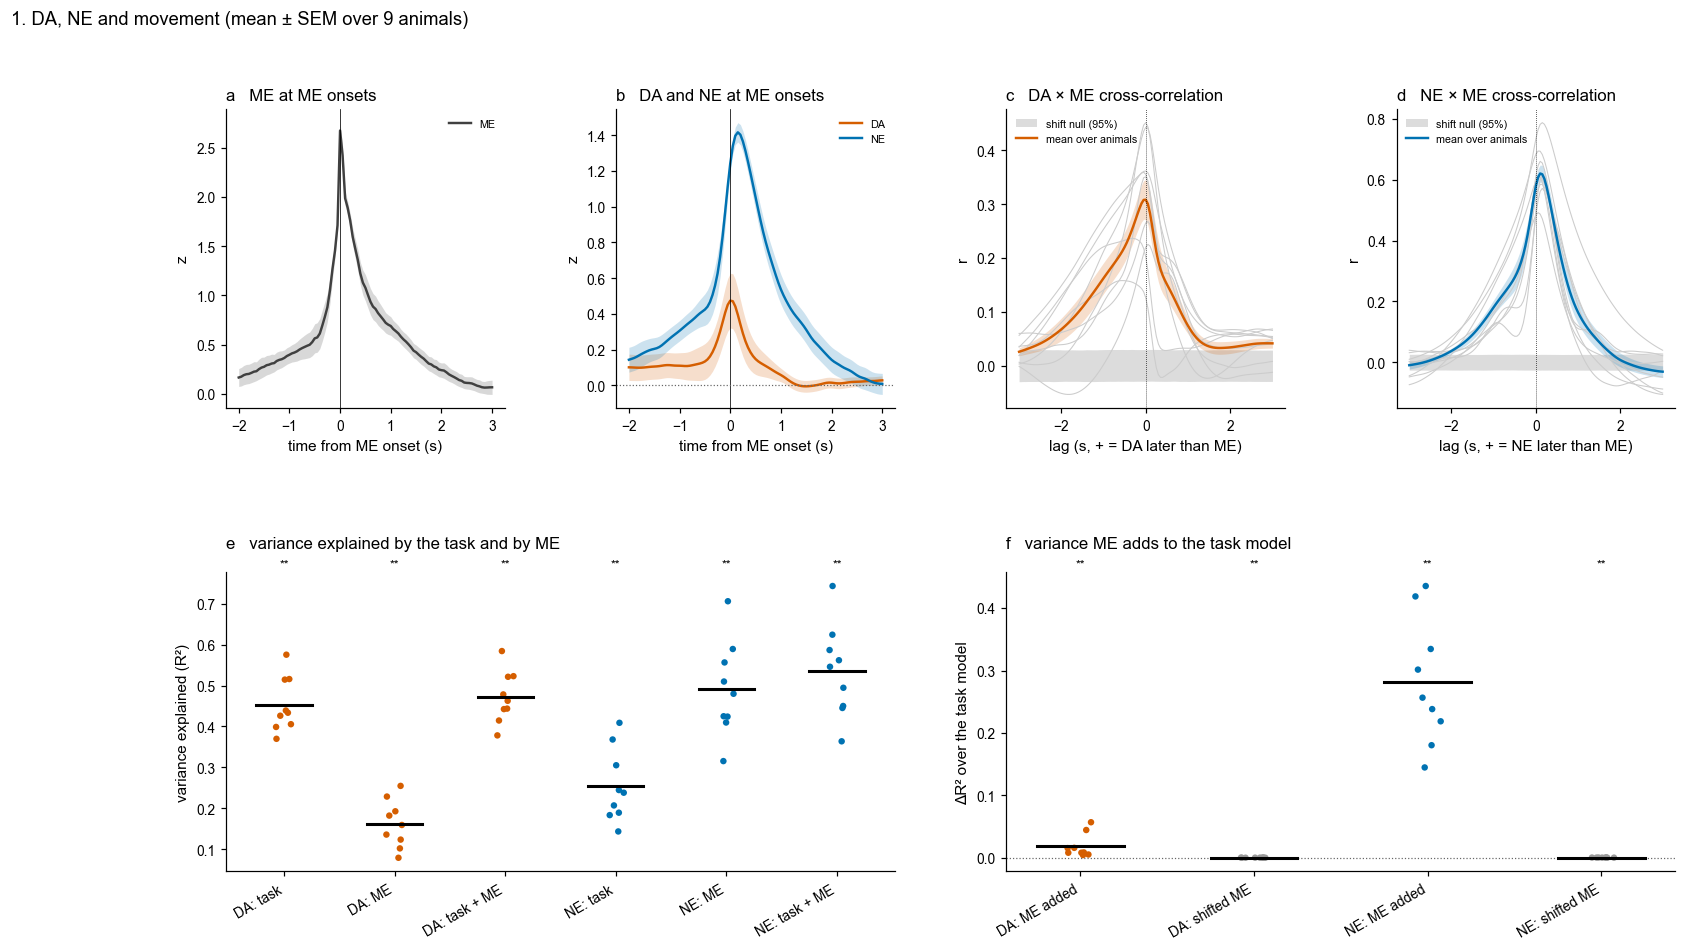

── ME added beyond the task, minus shifted-ME null
            measure   mean     sem       p  n
da_me_added_vs_null 0.0184 0.00629 0.00391  9
ne_me_added_vs_null   0.28  0.0335 0.00391  9



In [6]:
fig = plt.figure(figsize=(17, 9))
gs = GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.4, top=0.88)

ax = fig.add_subplot(gs[0, 0])
pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_onset["me"]), SIG_COLOR["me"], "ME")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("time from ME onset (s)")
ax.set_ylabel("z")
ax.set_title("a   ME at ME onsets", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[0, 1])
for s in ("da", "ne"):
    pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_onset[s]), SIG_COLOR[s], s.upper())
ax.axvline(0, color="k", lw=0.5)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_xlabel("time from ME onset (s)")
ax.set_ylabel("z")
ax.set_title("b   DA and NE at ME onsets", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[0, 2 + j])
    lo = st.group_means([b[0] for b in xc_null[s]], PAIR_SUBJECTS)[1].mean(0)
    hi = st.group_means([b[1] for b in xc_null[s]], PAIR_SUBJECTS)[1].mean(0)
    ax.fill_between(LAGS, lo, hi, color=NULL_COLOR, alpha=0.35, lw=0, label="shift null (95%)")
    curves = st.group_means(xc_curves[s], PAIR_SUBJECTS)[1]
    for c in curves:
        ax.plot(LAGS, c, color="0.8", lw=0.7)
    pu.plot_mean_sem(ax, LAGS, curves, SIG_COLOR[s], "mean over animals")
    ax.axvline(0, color="k", lw=0.5, ls=":")
    ax.set_xlabel(f"lag (s, + = {s.upper()} later than ME)")
    ax.set_ylabel("r")
    ax.set_title(f"{'cd'[j]}   {s.upper()} × ME cross-correlation", loc="left")
    ax.legend(fontsize=7, loc="upper left")
    style_ax(ax)

ax = fig.add_subplot(gs[1, :2])
cols = ["da_task", "da_me", "da_task_me", "ne_task", "ne_me", "ne_task_me"]
pu.strip_by_measure(ax, r2_animal, cols,
                    ["DA: task", "DA: ME", "DA: task + ME", "NE: task", "NE: ME", "NE: task + ME"],
                    [SIG_COLOR["da"]] * 3 + [SIG_COLOR["ne"]] * 3, "variance explained (R²)",
                    title="e   variance explained by the task and by ME", zero=False, connect=False)
ax = fig.add_subplot(gs[1, 2:])
pu.strip_by_measure(ax, r2_animal, ["da_me_added", "da_me_added_null", "ne_me_added", "ne_me_added_null"],
                    ["DA: ME added", "DA: shifted ME", "NE: ME added", "NE: shifted ME"],
                    [SIG_COLOR["da"], NULL_COLOR, SIG_COLOR["ne"], NULL_COLOR], "ΔR² over the task model",
                    title="f   variance ME adds to the task model", connect=False)
fig.suptitle(f"1. DA, NE and movement (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_08_1_movement", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
report("ME added beyond the task, minus shifted-ME null", r2_animal,
       ["da_me_added_vs_null", "ne_me_added_vs_null"])

### The model, in one session

The task model and the task + ME model of panels e–f, drawn for one session (the one whose NE ΔR² from
ME is closest to the median). Each sample of the signal is predicted as

$$\hat y(t) = b_0 + \sum_{e}\sum_{\ell = -1\,\mathrm{s}}^{+3.95\,\mathrm{s}} k_e(\ell)\,[\text{event } e \text{ at } t - \ell] + \sum_{L = -1\,\mathrm{s}}^{+2\,\mathrm{s}} w(L)\, \mathrm{ME}(t - L)$$

for event types *e* = go cue, rewarded outcome, unrewarded outcome, lick. One least-squares fit per
session and signal finds the kernels $k_e$ and the ME filter $w$ that minimize the squared error over
every sample of the session. The coefficients are refit here (same fits as panels e–f, without the
shifted-ME null).

- **a** inputs: event times and ME.
- **b, d** NE and DA with the task-model and task + ME predictions.
- **c** the task + ME prediction of NE split into what each event type and ME contribute.
- **e** the design matrix *X* over 6 s of panel a: one row per sample, one column per event type ×
  lag (1 where that event happened that long before the sample) and per ME lag (the ME value then).
  The prediction is $X\beta$.

In [ ]:
# Refit the task and task + ME models for every session, keeping the coefficients
KERNEL_T = np.arange(int(round(KERNEL_S[0] * FS)), int(round(KERNEL_S[1] * FS))) / FS
ME_T = np.arange(int(round(ME_LAGS_S[0] * FS)), int(round(ME_LAGS_S[1] * FS)) + 1) / FS
N_K = len(KERNEL_T)
EVENTS = ["go cue", "rewarded outcome", "unrewarded outcome", "lick"]     # fu.event_design order
EVENT_COLOR = {"go cue": OKABE_ITO["sky_blue"], "rewarded outcome": OKABE_ITO["orange"],
               "unrewarded outcome": "0.55", "lick": OKABE_ITO["bluish_green"],
               "ME": OKABE_ITO["reddish_purple"]}


def split_beta(beta):
    # {event: kernel, 'intercept': b0, 'ME': filter} from a task(+ME) coefficient vector
    k = {e: beta[i * N_K:(i + 1) * N_K] for i, e in enumerate(EVENTS)}
    k["intercept"] = beta[4 * N_K]
    if len(beta) > 4 * N_K + 1:
        k["ME"] = beta[4 * N_K + 1:]
    return k


model_fits = []
for p in pairs:
    me_cols = fu.lagged_columns(p["z"]["me"], FS, ME_LAGS_S)
    task = fu.task_residuals(p, KERNEL_S)
    both = fu.task_residuals(p, KERNEL_S, extra=me_cols)
    model_fits.append(dict(subject=p["subject"], session=p["session"],
                           **{f"{s}_{m}_{q}": f[f"{s}_{q}"] for s in ("da", "ne")
                              for m, f in (("task", task), ("both", both)) for q in ("beta", "r2")}))
print(f"refit {len(model_fits)} sessions")

refit 88 sessions


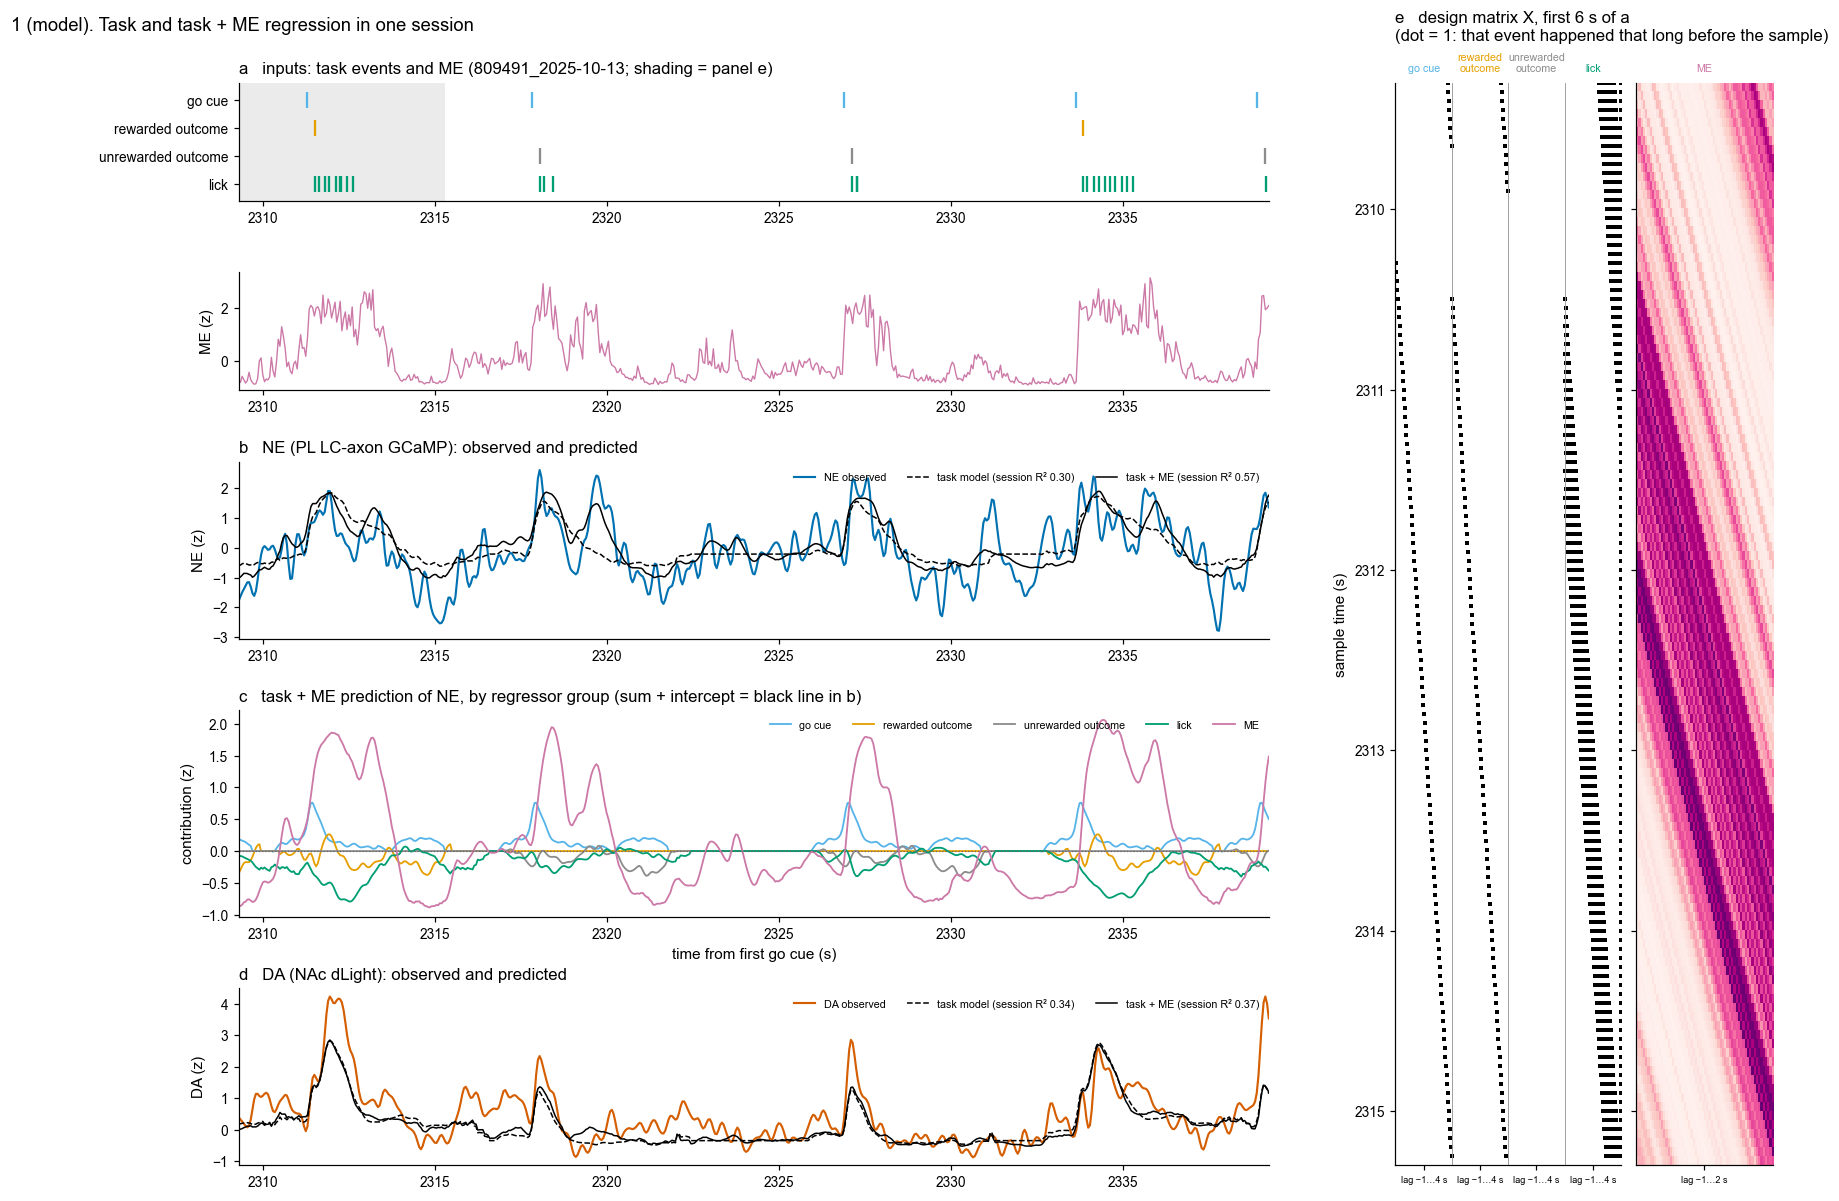

In [ ]:
WIN_S, X_WIN_S = 30.0, 6.0
d_r2 = np.array([m["ne_both_r2"] - m["ne_task_r2"] for m in model_fits])
ex_i = int(np.argmin(np.abs(d_r2 - np.median(d_r2))))
ex, exf = pairs[ex_i], model_fits[ex_i]
t = ex["t0"] + np.arange(len(ex["da"])) / FS
tr = ex["trials"]
cues = tr["goCue_start_time_in_session"].dropna().to_numpy()
start = cues[cues >= np.median(cues)][0] - 2.0
win = (t >= start) & (t < start + WIN_S)
i0, i1 = np.flatnonzero(win)[[0, -1]]

X_task = fu.event_design(ex, KERNEL_S)[i0:i1 + 1].toarray()
X_me = fu.lagged_columns(ex["z"]["me"], FS, ME_LAGS_S)[i0:i1 + 1]
tw = t[i0:i1 + 1]


def parts(sig, model):
    # each event type's and ME's contribution to the prediction in the window
    k = split_beta(exf[f"{sig}_{model}_beta"])
    out = {e: X_task[:, i * N_K:(i + 1) * N_K] @ k[e] for i, e in enumerate(EVENTS)}
    if "ME" in k:
        out["ME"] = X_me @ k["ME"]
    return out, k["intercept"]


fig = plt.figure(figsize=(18, 12))
gs = GridSpec(5, 2, figure=fig, width_ratios=[3, 1.1], height_ratios=[0.8, 0.8, 1.2, 1.4, 1.2],
              hspace=0.45, wspace=0.18, top=0.93)

# a: inputs
ax = fig.add_subplot(gs[0, 0])
responded = tr["animal_response"] < 2
rew = tr["earned_reward"].fillna(0).astype(bool) & responded
outc = tr["reward_outcome_time_in_session"]
rows = [("go cue", cues), ("rewarded outcome", outc[rew].dropna().to_numpy()),
        ("unrewarded outcome", outc[responded & ~rew].dropna().to_numpy()), ("lick", ex["licks"])]
for y, (name, times) in enumerate(rows):
    times = times[(times >= tw[0]) & (times <= tw[-1])]
    ax.plot(times, np.full(len(times), -y), "|", color=EVENT_COLOR[name], ms=10, mew=1.5)
ax.set_yticks(-np.arange(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.set_ylim(-len(rows) + 0.4, 0.6)
ax.set_xlim(tw[0], tw[-1])
ax.axvspan(tw[0], tw[0] + X_WIN_S, color="0.92", lw=0, zorder=0)
ax.set_title(f"a   inputs: task events and ME ({ex['session']}; shading = panel e)", loc="left")
style_ax(ax)
ax = fig.add_subplot(gs[1, 0], sharex=ax)
ax.plot(tw, ex["z"]["me"][i0:i1 + 1], color=EVENT_COLOR["ME"], lw=0.9)
ax.set_ylabel("ME (z)")
style_ax(ax)

# b, d: observed and predicted
for row, sig, letter in ((2, "ne", "b"), (4, "da", "d")):
    ax = fig.add_subplot(gs[row, 0], sharex=ax)
    ax.plot(tw, ex["z"][sig][i0:i1 + 1], color=SIG_COLOR[sig], lw=1.4, label=f"{sig.upper()} observed")
    for model, ls, lab in (("task", "--", "task model"), ("both", "-", "task + ME")):
        pr, b0 = parts(sig, model)
        ax.plot(tw, b0 + sum(pr.values()), color="k", ls=ls, lw=1.0,
                label=f"{lab} (session R² {exf[f'{sig}_{model}_r2']:.2f})")
    ax.set_ylabel(f"{sig.upper()} (z)")
    ax.legend(fontsize=7, ncol=3, loc="upper right")
    ax.set_title(f"{letter}   {SIG_LABEL[sig]}: observed and predicted", loc="left")
    style_ax(ax)

# c: NE prediction split by regressor group
ax = fig.add_subplot(gs[3, 0], sharex=ax)
pr, b0 = parts("ne", "both")
for name, y in pr.items():
    ax.plot(tw, y, color=EVENT_COLOR[name], lw=1.2, label=name)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
ax.set_ylabel("contribution (z)")
ax.legend(fontsize=7, ncol=5, loc="upper right")
ax.set_title("c   task + ME prediction of NE, by regressor group (sum + intercept = black line in b)",
             loc="left")
style_ax(ax)
ax.set_xlabel("time from first go cue (s)")

# e: design matrix
sub = gs[:, 1].subgridspec(1, 2, width_ratios=[4 * N_K, 4 * len(ME_T)], wspace=0.08)
n_rows = int(X_WIN_S * FS)
ax = fig.add_subplot(sub[0])
rr, cc = np.nonzero(X_task[:n_rows])         # the 1s, drawn as dots so single columns stay visible
ax.scatter(cc + 0.5, tw[0] + rr / FS, s=7, color="k", marker="s", lw=0)
ax.set_xlim(0, 4 * N_K)
ax.set_ylim(tw[0] + X_WIN_S, tw[0])
for i, e in enumerate(EVENTS):
    ax.axvline(i * N_K, color="0.6", lw=0.6)
    ax.text((i + 0.5) * N_K, tw[0] - 0.05, e.replace(" outcome", "\noutcome"), ha="center",
            va="bottom", fontsize=7, color=EVENT_COLOR[e])
ax.set_xticks([(i + 0.5) * N_K for i in range(4)])
ax.set_xticklabels(["lag −1…4 s"] * 4, fontsize=6)
ax.set_ylabel("sample time (s)")
ax.set_title("e   design matrix X, first 6 s of a\n(dot = 1: that event happened that long before the sample)", loc="left", pad=28)
ax2 = fig.add_subplot(sub[1], sharey=ax)
ax2.imshow(X_me[:n_rows], aspect="auto", cmap="RdPu", interpolation="nearest",
           extent=[0, len(ME_T), tw[0] + X_WIN_S, tw[0]], vmin=-1, vmax=3)
ax2.text(len(ME_T) / 2, tw[0] - 0.05, "ME", ha="center", va="bottom", fontsize=7,
         color=EVENT_COLOR["ME"])
ax2.set_xticks([len(ME_T) / 2])
ax2.set_xticklabels(["lag −1…2 s"], fontsize=6)
plt.setp(ax2.get_yticklabels(), visible=False)
fig.suptitle("1 (model). Task and task + ME regression in one session", x=0.01, ha="left")
save_fig(fig, "fip_08_1_model", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. The DA–NE correlation with task and movement removed

Zero-lag Pearson r of DA and NE per session: raw (z-scored), after removing what lagged ME
explains, after removing the task model, and after removing task + ME (the residuals of the fits in
section 1).

── DA–NE zero-lag r
           measure   mean    sem       p  n
               raw  0.255 0.0389 0.00391  9
          minus_me 0.0623 0.0192  0.0195  9
        minus_task 0.0189 0.0305   0.496  9
     minus_task_me 0.0647 0.0208  0.0273  9
task_me_minus_task 0.0458 0.0142  0.0273  9
      me_minus_raw -0.193 0.0273 0.00391  9



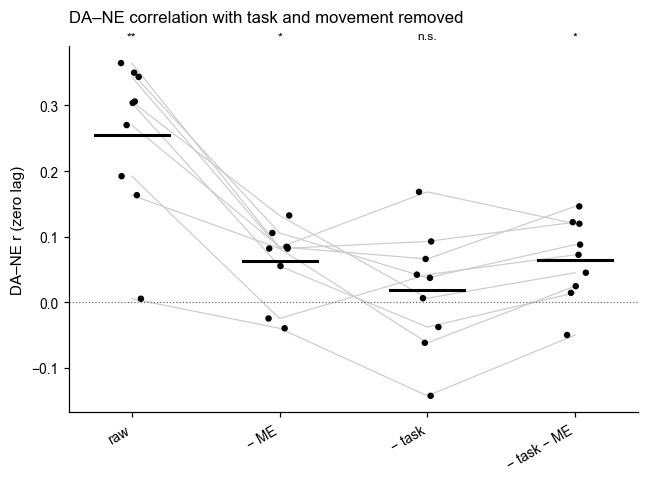

In [7]:
rows = []
for p in pairs:
    f = resid[p["session"]]
    rows.append(dict(
        subject=p["subject"], session=p["session"],
        raw=np.corrcoef(p["z"]["da"], p["z"]["ne"])[0, 1],
        minus_me=np.corrcoef(f["me_only"]["da_res"], f["me_only"]["ne_res"])[0, 1],
        minus_task=np.corrcoef(f["task"]["da_res"], f["task"]["ne_res"])[0, 1],
        minus_task_me=np.corrcoef(f["both"]["da_res"], f["both"]["ne_res"])[0, 1]))
coup_sess = pd.DataFrame(rows)
coup_animal = st.animal_means(coup_sess, ["raw", "minus_me", "minus_task", "minus_task_me"],
                              by_session=False)
coup_animal["task_me_minus_task"] = coup_animal["minus_task_me"] - coup_animal["minus_task"]
coup_animal["me_minus_raw"] = coup_animal["minus_me"] - coup_animal["raw"]
report("DA–NE zero-lag r", coup_animal, list(coup_animal))

fig, ax = plt.subplots(figsize=(6, 4.5))
pu.strip_by_measure(ax, coup_animal, ["raw", "minus_me", "minus_task", "minus_task_me"],
                    ["raw", "− ME", "− task", "− task − ME"], ["k"] * 4, "DA–NE r (zero lag)",
                    title="DA–NE correlation with task and movement removed")
fig.tight_layout()
save_fig(fig, "fip_08_2_coupling", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. RPE coding and movement

Per trial, the mean of each signal 0–2 s after the outcome minus its mean 1 s before the go cue
(`fu.trial_measures`; ME the same way). **a.** Outcome-aligned ME by outcome. **b.** `fu.fit_rpe_terms`
per session for DA, NE and ME (`response ~ reward + RPE·rewarded + RPE·unrewarded + RT + trial
position`), on responded trials without extra water, leaving out flat-RPE sessions. **c.** The DA
and NE terms again with the trial's ME response as a further covariate.

In [8]:
TERMS = ["reward", "rpe_rew", "rpe_unrew"]
fit_rows, out_traces = [], {o: [] for o in OUT_COLOR}
for p in pairs:
    tr = fu.trial_measures(p, {"out": OUTCOME_WIN}, baseline=BASELINE)
    cue = tr["goCue_start_time_in_session"].to_numpy()
    out = tr["reward_outcome_time_in_session"].to_numpy()
    me = p["z"]["me"]
    tr["me_pre"] = su.window_mean_grid(me, p["t0"], FS, cue, *BASELINE)
    tr["me_out"] = su.window_mean_grid(me, p["t0"], FS, out, *OUTCOME_WIN) - tr["me_pre"]
    tr = tr[tr["responded"] & ~(tr["extra_reward"].fillna(0) > 0)]
    for o, m in (("rewarded", tr["rewarded"]), ("unrewarded", ~tr["rewarded"])):
        out_traces[o].append((p["subject"], np.nanmean(
            su.peri_event_grid(me, p["t0"], FS, tr.loc[m, "reward_outcome_time_in_session"], ETA_LAGS), 0)))
    if tr.groupby("rewarded")["RPE_earned"].std().min() < MIN_RPE_SD:
        continue
    r = dict(subject=p["subject"], session=p["session"])
    for s in SIG:
        b = fu.fit_rpe_terms(tr, f"{s}_out", covariates=RPE_COVARIATES)
        r.update({f"{s}_{t}": b[t] for t in TERMS})
    for s in ("da", "ne"):
        b = fu.fit_rpe_terms(tr, f"{s}_out", covariates=RPE_COVARIATES + ["me_out"])
        r.update({f"{s}_{t}_withME": b[t] for t in TERMS})
        r[f"{s}_me_beta"] = b["me_out"]
    fit_rows.append(r)
rpe_sess = pd.DataFrame(fit_rows)
rpe_animal = st.animal_means(rpe_sess, [c for c in rpe_sess if c not in ("subject", "session")],
                             by_session=False)
print(f"{len(rpe_sess)} sessions in the RPE fits ({len(pairs) - len(rpe_sess)} flat-RPE sessions left out)")
report("RPE terms of DA, NE and ME", rpe_animal, [f"{s}_{t}" for s in SIG for t in TERMS])
report("DA and NE terms with ME as a covariate, and the ME coefficient", rpe_animal,
       [f"{s}_{t}_withME" for s in ("da", "ne") for t in TERMS] + ["da_me_beta", "ne_me_beta"])
for s in ("da", "ne"):
    for t in TERMS:
        rpe_animal[f"{s}_{t}_change"] = rpe_animal[f"{s}_{t}_withME"] - rpe_animal[f"{s}_{t}"]
report("change in DA and NE terms when ME is added", rpe_animal,
       [f"{s}_{t}_change" for s in ("da", "ne") for t in TERMS])

87 sessions in the RPE fits (1 flat-RPE sessions left out)
── RPE terms of DA, NE and ME
     measure  mean    sem       p  n
   da_reward  1.05  0.115 0.00391  9
  da_rpe_rew 0.091  0.091   0.359  9
da_rpe_unrew 0.457 0.0495 0.00391  9
   ne_reward 0.228 0.0394 0.00781  9
  ne_rpe_rew 0.326   0.03 0.00391  9
ne_rpe_unrew  0.16 0.0571  0.0273  9
   me_reward 0.721 0.0855 0.00391  9
  me_rpe_rew 0.154 0.0639  0.0742  9
me_rpe_unrew 0.161 0.0781  0.0977  9

── DA and NE terms with ME as a covariate, and the ME coefficient
            measure   mean    sem       p  n
   da_reward_withME  0.934  0.105 0.00391  9
  da_rpe_rew_withME 0.0914 0.0944   0.359  9
da_rpe_unrew_withME  0.443 0.0468 0.00391  9
   ne_reward_withME -0.292 0.0779 0.00781  9
  ne_rpe_rew_withME  0.222 0.0643 0.00391  9
ne_rpe_unrew_withME  0.045 0.0432   0.652  9
         da_me_beta  0.125 0.0509  0.0391  9
         ne_me_beta  0.708 0.0249 0.00391  9

── change in DA and NE terms when ME is added
            measure   

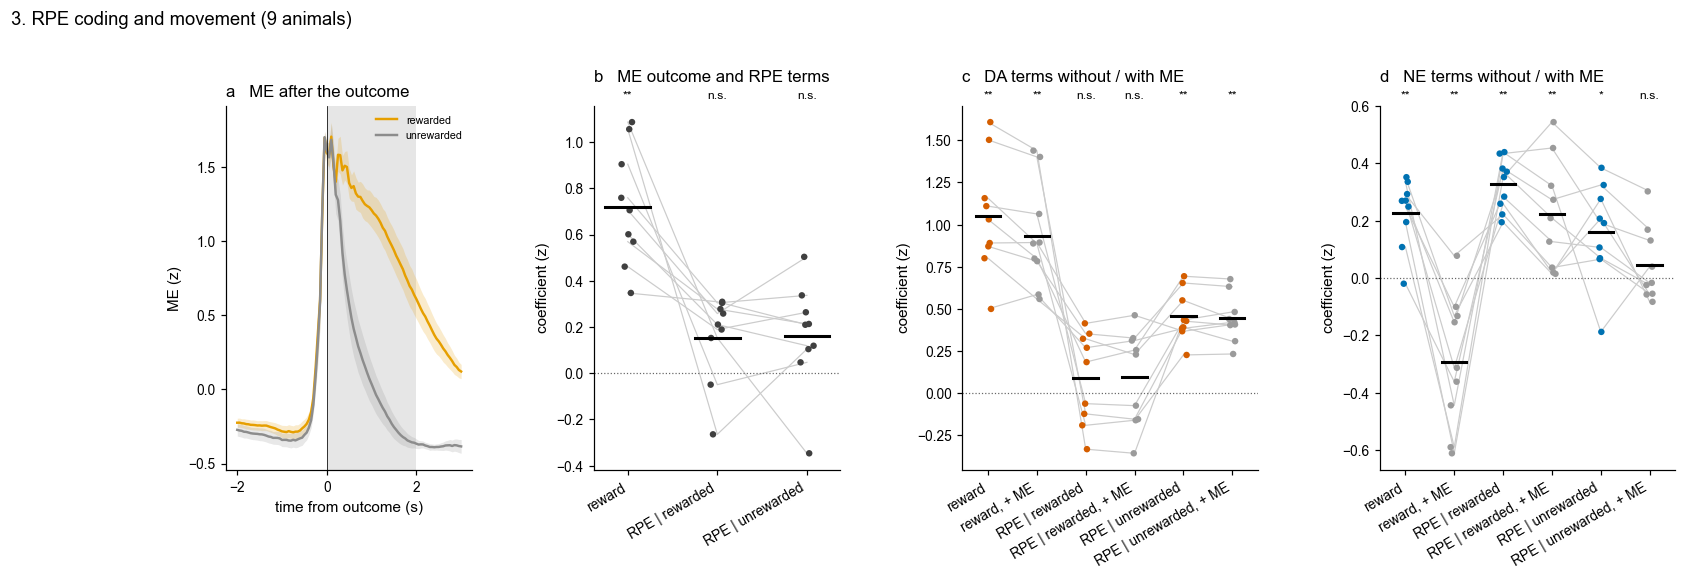

In [9]:
TERM_LABEL = {"reward": "reward", "rpe_rew": "RPE | rewarded", "rpe_unrew": "RPE | unrewarded"}
fig = plt.figure(figsize=(17, 4.8))
gs = GridSpec(1, 4, figure=fig, wspace=0.45, top=0.8, width_ratios=[1, 1, 1.2, 1.2])

ax = fig.add_subplot(gs[0])
for o in OUT_COLOR:
    pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(out_traces[o]), OUT_COLOR[o], o)
ax.axvline(0, color="k", lw=0.5)
ax.axvspan(*OUTCOME_WIN, color="0.9", lw=0, zorder=0)
ax.set_xlabel("time from outcome (s)")
ax.set_ylabel("ME (z)")
ax.set_title("a   ME after the outcome", loc="left")
ax.legend(fontsize=7)
style_ax(ax)

ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, rpe_animal, [f"me_{t}" for t in TERMS], [TERM_LABEL[t] for t in TERMS],
                    [SIG_COLOR["me"]] * 3, "coefficient (z)", title="b   ME outcome and RPE terms")
for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[2 + j])
    cols = [c for t in TERMS for c in (f"{s}_{t}", f"{s}_{t}_withME")]
    labels = [l for t in TERMS for l in (TERM_LABEL[t], f"{TERM_LABEL[t]}, + ME")]
    pu.strip_by_measure(ax, rpe_animal, cols, labels, [SIG_COLOR[s], NULL_COLOR] * 3,
                        "coefficient (z)", title=f"{'cd'[j]}   {s.upper()} terms without / with ME")
fig.suptitle(f"3. RPE coding and movement ({N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_08_3_rpe", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. Movement at large DA and NE transients

Large transients and partners as in `fip_07` Figure 2 (`fu.large_transients`: prominence ≥ 2 z;
partner = a peak ≥ 1 z in the other signal within ±0.5 s). ME is averaged around each group's
peaks, and its mean over −0.5 to +0.5 s compared between solo and partnered transients.

── ME around large transients (z, −0.5 to +0.5 s)
           measure   mean    sem       p  n
        DA with NE  0.723 0.0611 0.00391  9
           DA solo  0.301 0.0469 0.00781  9
        NE with DA  0.697 0.0622 0.00391  9
           NE solo   0.31 0.0928 0.00391  9
DA: solo − with NE -0.422 0.0524 0.00391  9
NE: solo − with DA -0.387  0.066 0.00391  9



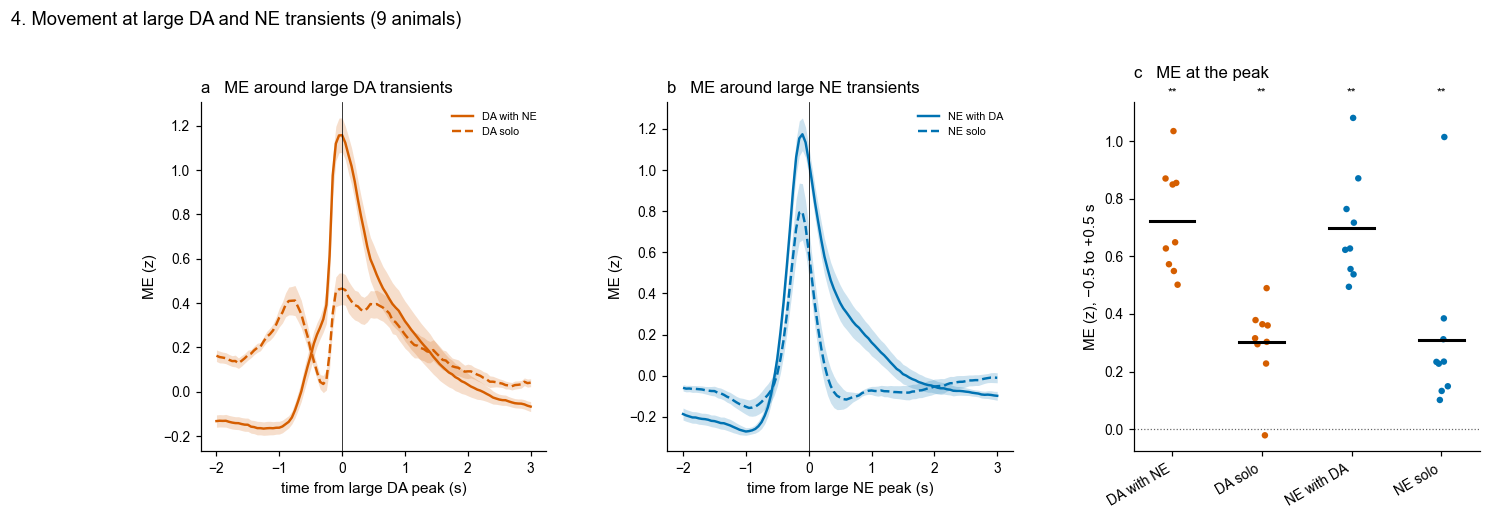

In [10]:
GROUPS = [("da", True), ("da", False), ("ne", True), ("ne", False)]
GROUP_LABEL = {("da", True): "DA with NE", ("da", False): "DA solo",
               ("ne", True): "NE with DA", ("ne", False): "NE solo"}
eta_tr = {g: [] for g in GROUPS}
rows = []
for p in pairs:
    z = p["z"]
    r = dict(subject=p["subject"], session=p["session"])
    for s, o in (("da", "ne"), ("ne", "da")):
        big = fu.large_transients(z[s], z[o], p["t0"], FS, LARGE_PROM, PARTNER_PROM, MATCH_WIN_S, MIN_SEP_S)
        for partner in (True, False):
            t = big.loc[big["partner"] == partner, "t"].to_numpy()
            if len(t) < 3:
                continue
            eta_tr[(s, partner)].append((p["subject"], np.nanmean(su.peri_event_grid(z["me"], p["t0"], FS, t, ETA_LAGS), 0)))
            r[GROUP_LABEL[(s, partner)]] = np.nanmean(su.window_mean_grid(z["me"], p["t0"], FS, t, *PEAK_WIN))
    rows.append(r)
tr_sess = pd.DataFrame(rows)
tr_animal = st.animal_means(tr_sess, [GROUP_LABEL[g] for g in GROUPS], by_session=False)
tr_animal["DA: solo − with NE"] = tr_animal["DA solo"] - tr_animal["DA with NE"]
tr_animal["NE: solo − with DA"] = tr_animal["NE solo"] - tr_animal["NE with DA"]
report("ME around large transients (z, −0.5 to +0.5 s)", tr_animal, list(tr_animal))

fig = plt.figure(figsize=(15, 4.6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35, top=0.8)
for j, s in enumerate(("da", "ne")):
    ax = fig.add_subplot(gs[j])
    for partner, ls in ((True, "-"), (False, "--")):
        pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_tr[(s, partner)]), SIG_COLOR[s],
                         GROUP_LABEL[(s, partner)], ls=ls)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(f"time from large {s.upper()} peak (s)")
    ax.set_ylabel("ME (z)")
    ax.set_title(f"{'ab'[j]}   ME around large {s.upper()} transients", loc="left")
    ax.legend(fontsize=7)
    style_ax(ax)
ax = fig.add_subplot(gs[2])
pu.strip_by_measure(ax, tr_animal, [GROUP_LABEL[g] for g in GROUPS], [GROUP_LABEL[g] for g in GROUPS],
                    [SIG_COLOR["da"], SIG_COLOR["da"], SIG_COLOR["ne"], SIG_COLOR["ne"]],
                    "ME (z), −0.5 to +0.5 s", title="c   ME, mean −0.5 to +0.5 s", connect=False)
fig.suptitle(f"4. Movement at large DA and NE transients ({N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_08_4_transients", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

### 4, peak ME

The window mean in panel c weighs a tall, narrow ME peak and a low, broad elevation alike. Here,
per animal, the maximum of that animal's average ME trace within ±0.5 s of the transient peak (the
traces of panels a–b), and when it occurs. The maximum is taken from the animal's average trace,
not from single events, so noise in single events does not inflate it.

In [ ]:
in_win = (ETA_LAGS >= PEAK_WIN[0]) & (ETA_LAGS <= PEAK_WIN[1])
peak_rows = []
for g in GROUPS:
    subj, traces = zip(*eta_tr[g])
    labels, avg = st.group_means(traces, subj)
    for a, tr in zip(labels, avg):
        k = int(np.nanargmax(tr[in_win]))
        peak_rows.append(dict(subject=a, group=GROUP_LABEL[g], peak=tr[in_win][k],
                              peak_time=ETA_LAGS[in_win][k]))
peak_long = pd.DataFrame(peak_rows)
peak_animal = peak_long.pivot(index="subject", columns="group", values="peak")[[GROUP_LABEL[g] for g in GROUPS]]
time_animal = peak_long.pivot(index="subject", columns="group", values="peak_time")[[GROUP_LABEL[g] for g in GROUPS]]
report("peak ME within ±0.5 s (z)", peak_animal, list(peak_animal))
report("time of peak ME (s from transient peak)", time_animal, list(time_animal))

cmp_rows = []
for x, y in (("NE solo", "DA solo"), ("NE with DA", "DA with NE"), ("DA solo", "DA with NE"),
             ("NE solo", "NE with DA")):
    d = peak_animal[x] - peak_animal[y]
    mean, pv, n = st.wilcoxon_animals(d)
    cmp_rows.append(dict(comparison=f"{x} − {y}", mean_diff=mean, p=pv,
                         animals_positive=f"{int((d > 0).sum())}/{n}"))
peak_cmp = pd.DataFrame(cmp_rows)
print("── peak ME, group against group (Wilcoxon on animal differences)")
print(peak_cmp.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

fig = plt.figure(figsize=(10, 4.6))
gs = GridSpec(1, 2, figure=fig, wspace=0.4, top=0.8)
cols = [GROUP_LABEL[g] for g in GROUPS]
colors = [SIG_COLOR["da"], SIG_COLOR["da"], SIG_COLOR["ne"], SIG_COLOR["ne"]]
ax = fig.add_subplot(gs[0])
pu.strip_by_measure(ax, peak_animal, cols, cols, colors, "peak ME (z) within ±0.5 s",
                    title="d   peak ME", connect=False)
ax = fig.add_subplot(gs[1])
pu.strip_by_measure(ax, time_animal, cols, cols, colors, "time of peak ME (s)",
                    title="e   when ME peaks (+ = after the transient)", connect=False)
fig.suptitle(f"4. Peak movement at large DA and NE transients ({N_ANIMALS} animals)", x=0.01, ha="left")
save_fig(fig, "fip_08_4_transients_peak", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Instructed and uninstructed movement

Four kinds of movement onset, with `men_00`'s definitions:

- **instructed lick bouts**, starting ≤ 2 s after a go cue, split by that trial's outcome (the
  bout's first lick is the choice, so the rewarded ones carry the reward response);
- **uninstructed lick bouts**, starting more than 2 s after the latest go cue (library
  `annotate_lick_bouts`, 0.7 s gap);
- **movement without licking**: ME onsets with no lick from 0.5 s before to 1 s after, outside
  task events (`bu.label_context` "quiet": not within 1.5 s after an outcome or an ignored cue).

Response: mean 0–1 s after onset minus mean −1 to −0.2 s.

In [11]:
TYPES = list(TYPE_COLOR)
eta_type = {(k, s): [] for k in TYPES for s in SIG}
rows = []
for p in pairs:
    tr = p["trials"]
    cues = tr["goCue_start_time_in_session"].to_numpy()
    rewarded = (tr["earned_reward"].fillna(0).astype(bool) & (tr["animal_response"] < 2)).to_numpy()
    span = (np.nanmin(cues), np.nanmax(cues) + 10.0)
    le = p["lick_events"]
    bouts = bu.lick_bouts(le[(le.timestamps >= span[0]) & (le.timestamps < span[1])])
    instr, uninstr = bu.classify_bout_times(bouts["onset"], cues[np.isfinite(cues)],
                                            go_response_window_s=INSTRUCTED_S,
                                            iti_min_post_cue_s=INSTRUCTED_S, iti_min_pre_next_s=0.0)
    order = np.argsort(cues)
    k = order[np.searchsorted(cues[order], instr, side="right") - 1]   # trial of each instructed bout
    ev = p["me_onsets"]
    ev = ev[(ev >= span[0]) & (ev < span[1])]
    ev = ev[~su.near_any(ev, p["licks"], *LICK_WIN)]
    ev = ev[bu.label_context(ev, tr, p["licks"]) == "quiet"]
    onsets = {"instructed, rewarded": instr[rewarded[k]], "instructed, unrewarded": instr[~rewarded[k]],
              "uninstructed lick bout": uninstr, "movement, no lick": ev}
    r = dict(subject=p["subject"], session=p["session"])
    for typ, t in onsets.items():
        r[f"n {typ}"] = len(t)
        if len(t) < 3:
            continue
        for s in SIG:
            x = p["z"][s]
            eta_type[(typ, s)].append((p["subject"], np.nanmean(su.peri_event_grid(x, p["t0"], FS, t, ETA_LAGS), 0)))
            resp = (su.window_mean_grid(x, p["t0"], FS, t, *RESP_WIN)
                    - su.window_mean_grid(x, p["t0"], FS, t, *PRE_WIN))
            r[f"{s}: {typ}"] = np.nanmean(resp)
    rows.append(r)
type_sess = pd.DataFrame(rows)
type_animal = st.animal_means(type_sess, [c for c in type_sess if c not in ("subject", "session")],
                              by_session=False)
print("events per session (mean over animals):")
print(type_animal[[f"n {t}" for t in TYPES]].mean().round(1).to_string())
print()
report("responses (z, 0–1 s minus −1 to −0.2 s)", type_animal, [f"{s}: {t}" for s in SIG for t in TYPES])
for s in ("da", "ne"):
    type_animal[f"{s}: uninstructed − instructed unrewarded"] = (
        type_animal[f"{s}: uninstructed lick bout"] - type_animal[f"{s}: instructed, unrewarded"])
    type_animal[f"{s}: no-lick movement − uninstructed bout"] = (
        type_animal[f"{s}: movement, no lick"] - type_animal[f"{s}: uninstructed lick bout"])
report("paired differences", type_animal,
       [f"{s}: {d}" for s in ("da", "ne")
        for d in ("uninstructed − instructed unrewarded", "no-lick movement − uninstructed bout")])

events per session (mean over animals):
n instructed, rewarded      223.1
n instructed, unrewarded    255.3
n uninstructed lick bout    211.6
n movement, no lick         102.7

── responses (z, 0–1 s minus −1 to −0.2 s)
                   measure    mean    sem       p  n
  da: instructed, rewarded       2  0.121 0.00391  9
da: instructed, unrewarded   0.315 0.0927  0.0117  9
da: uninstructed lick bout -0.0466 0.0565    0.57  9
     da: movement, no lick  0.0822 0.0296  0.0391  9
  ne: instructed, rewarded    1.27 0.0926 0.00391  9
ne: instructed, unrewarded   0.911  0.104 0.00391  9
ne: uninstructed lick bout   0.563 0.0643 0.00391  9
     ne: movement, no lick   0.525  0.113 0.00781  9
  me: instructed, rewarded    1.63  0.123 0.00391  9
me: instructed, unrewarded    1.01  0.173 0.00391  9
me: uninstructed lick bout   0.563  0.066 0.00391  9
     me: movement, no lick   0.469 0.0988 0.00391  9

── paired differences
                                 measure    mean    sem       p  n
d

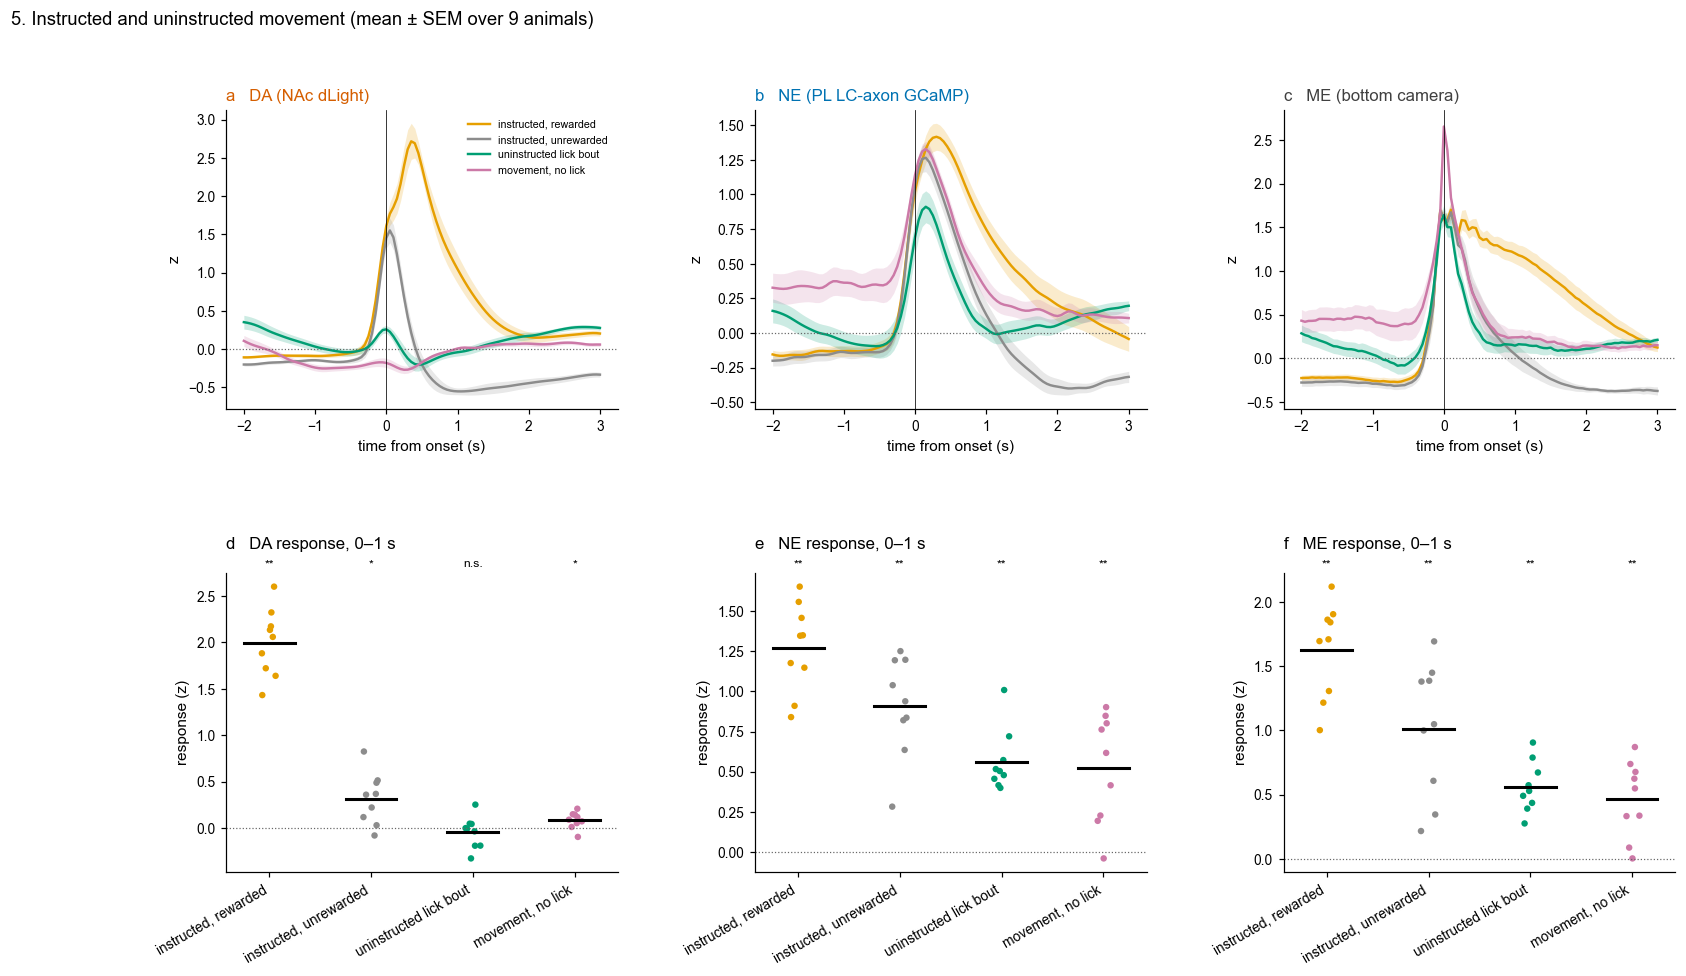

In [12]:
fig = plt.figure(figsize=(17, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35, top=0.88)
for j, s in enumerate(SIG):
    ax = fig.add_subplot(gs[0, j])
    for typ in TYPES:
        pu.plot_mean_sem(ax, ETA_LAGS, animal_traces(eta_type[(typ, s)]), TYPE_COLOR[typ], typ)
    ax.axvline(0, color="k", lw=0.5)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
    ax.set_xlabel("time from onset (s)")
    ax.set_ylabel("z")
    ax.set_title(f"{'abc'[j]}   {SIG_LABEL[s]}", loc="left", color=SIG_COLOR[s])
    if j == 0:
        ax.legend(fontsize=7)
    style_ax(ax)
    ax = fig.add_subplot(gs[1, j])
    pu.strip_by_measure(ax, type_animal, [f"{s}: {t}" for t in TYPES], TYPES,
                        [TYPE_COLOR[t] for t in TYPES], "response (z)",
                        title=f"{'def'[j]}   {s.upper()} response, 0–1 s", connect=False)
fig.suptitle(f"5. Instructed and uninstructed movement (mean ± SEM over {N_ANIMALS} animals)",
             x=0.01, ha="left")
save_fig(fig, "fip_08_5_movement_types", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## Supplementary: fitted kernels

The kernels of section 1's models, session kernels averaged within animal (mean ± SEM over animals).
Solid: task model; dashed: task + ME. Each event kernel is that event's response on top of every other
regressor: the outcome kernels sit on top of the go-cue and lick kernels of the same trial, and the
lick kernel is the response per single lick. The ME filter is the response per 1 z of ME at each lag
(+ lag: signal after ME).

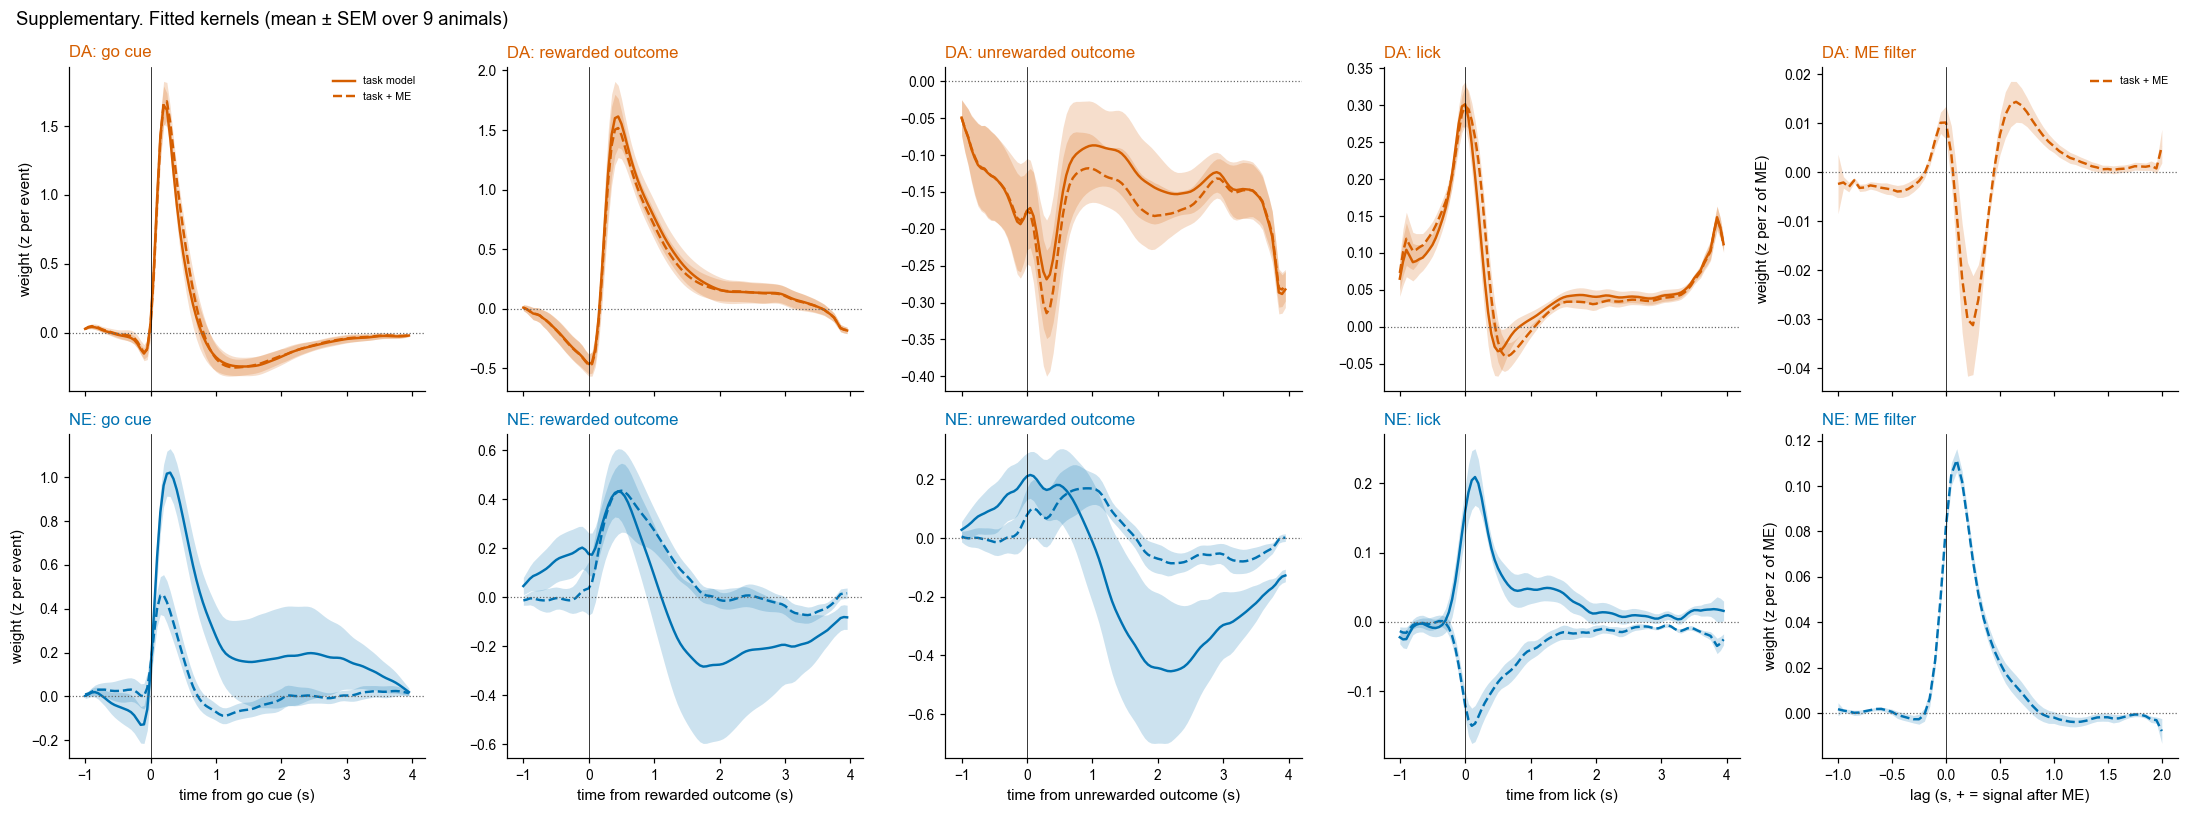

In [ ]:
fits = pd.DataFrame(model_fits)
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex="col")
for r, sig in enumerate(("da", "ne")):
    for c, name in enumerate(EVENTS + ["ME"]):
        ax = axes[r, c]
        for model, ls in (("task", "-"), ("both", "--")):
            ks = [split_beta(b) for b in fits[f"{sig}_{model}_beta"]]
            if name not in ks[0]:
                continue
            x = ME_T if name == "ME" else KERNEL_T
            curves = st.group_means([k[name] for k in ks], fits["subject"])[1]
            pu.plot_mean_sem(ax, x, curves, SIG_COLOR[sig],
                             "task + ME" if model == "both" else "task model", ls=ls)
        ax.axvline(0, color="k", lw=0.5)
        ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":")
        ax.set_title(f"{sig.upper()}: {name if name != 'ME' else 'ME filter'}", loc="left",
                     color=SIG_COLOR[sig])
        if r == 1:
            ax.set_xlabel("lag (s, + = signal after ME)" if name == "ME" else f"time from {name} (s)")
        if c == 0:
            ax.set_ylabel("weight (z per event)")
        if c == 4:
            ax.set_ylabel("weight (z per z of ME)")
        if r == 0 and c in (0, 4):
            ax.legend(fontsize=7)
        style_ax(ax)
fig.suptitle(f"Supplementary. Fitted kernels (mean ± SEM over {N_ANIMALS} animals)", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "fip_08_S1_kernels", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Numbers

One row per measure: mean over animals, Wilcoxon p against zero, animals positive.

In [13]:
def row(section, measure, df, col):
    v = df[col]
    m, p, n = st.wilcoxon_animals(v)
    return dict(section=section, measure=measure, mean=round(m, 3), p=round(p, 4),
                animals_positive=f"{int((v > 0).sum())}/{n}")


S = [row("0b", f"{PAIR_LABEL[pr]} {m}", pair_animal, f"{m}_{PAIR_KEY[pr]}")
     for m in ("peak_r", "peak_lag", "coh_effect") for pr in PAIRS]
S += [row("0b", f"{PAIR_LABEL[pr]} coherence − null, {b}", band_animal, f"coh_effect[{b}]_{PAIR_KEY[pr]}")
      for b in COH_BANDS for pr in PAIRS]
S += [row("1", f"{s.upper()} peak r with ME", xc_animal, f"{s}_peak_r") for s in ("da", "ne")]
S += [row("1", f"{s.upper()} peak lag vs ME (s, + = later)", xc_animal, f"{s}_peak_lag") for s in ("da", "ne")]
S += [row("1", f"{s.upper()} R², {lab}", r2_animal, f"{s}_{c}")
      for s in ("da", "ne") for c, lab in (("task", "task"), ("me", "ME alone"), ("task_me", "task + ME"))]
S += [row("1", f"{s.upper()} ΔR² from ME minus shifted-ME null", r2_animal, f"{s}_me_added_vs_null")
      for s in ("da", "ne")]
S += [row("2", f"DA–NE r, {c}", coup_animal, c) for c in ("raw", "minus_me", "minus_task", "minus_task_me")]
S += [row("2", "DA–NE r: (− task − ME) minus (− task)", coup_animal, "task_me_minus_task")]
S += [row("3", f"{s.upper()} {TERM_LABEL[t]}", rpe_animal, f"{s}_{t}") for s in SIG for t in TERMS]
S += [row("3", f"{s.upper()} {TERM_LABEL[t]}: change with ME", rpe_animal, f"{s}_{t}_change")
      for s in ("da", "ne") for t in TERMS]
S += [row("4", c, tr_animal, c) for c in tr_animal]
S += [row("4", f"peak ME, {c}", peak_animal, c) for c in peak_animal]
S += [row("5", f"{s.upper()} {t}", type_animal, f"{s}: {t}") for s in SIG for t in TYPES]
S += [row("5", c, type_animal, c) for c in type_animal if " − " in c]
summary = pd.DataFrame(S).set_index(["section", "measure"])
summary

mean       p animals_positive
section measure                                                                 
1       DA peak r with ME                         0.326  0.0039              9/9
        NE peak r with ME                         0.627  0.0039              9/9
        DA peak lag vs ME (s, + = later)         -0.059  0.4838              3/9
        NE peak lag vs ME (s, + = later)          0.171  0.0039              9/9
        DA R², task                               0.453  0.0039              9/9
        DA R², ME alone                           0.162  0.0039              9/9
        DA R², task + ME                          0.472  0.0039              9/9
        NE R², task                               0.254  0.0039              9/9
        NE R², ME alone                           0.491  0.0039              9/9
        NE R², task + ME                          0.535  0.0039              9/9
        DA ΔR² from ME minus shifted-ME null      0.018  0.0039              9/9
        NE ΔR² from ME minus shifted-ME null      0.280  0.0039              9/9
2       DA–NE r, raw                              0.255  0.0039              9/9
        DA–NE r, minus_me                         0.062  0.0195              7/9
        DA–NE r, minus_task                       0.019  0.4961              6/9
        DA–NE r, minus_task_me                    0.065  0.0273              8/9
        DA–NE r: (− task − ME) minus (− task)     0.046  0.0273              8/9
3       DA reward                                 1.052  0.0039              9/9
        DA RPE | rewarded                         0.091  0.3594              5/9
        DA RPE | unrewarded                       0.457  0.0039              9/9
        NE reward                                 0.228  0.0078              8/9
        NE RPE | rewarded                         0.326  0.0039              9/9
        NE RPE | unrewarded                       0.160  0.0273              8/9
        ME reward                                 0.721  0.0039              9/9
        ME RPE | rewarded                         0.154  0.0742              7/9
        ME RPE | unrewarded                       0.161  0.0977              8/9
        DA reward: change with ME                -0.118  0.0273              2/9
        DA RPE | rewarded: change with ME         0.000  0.8203              4/9
        DA RPE | unrewarded: change with ME      -0.014  0.7344              4/9
        NE reward: change with ME                -0.520  0.0039              0/9
        NE RPE | rewarded: change with ME        -0.104  0.1289              2/9
        NE RPE | unrewarded: change with ME      -0.115  0.0742              1/9
4       DA with NE                                0.723  0.0039              9/9
        DA solo                                   0.301  0.0078              8/9
        NE with DA                                0.697  0.0039              9/9
        NE solo                                   0.310  0.0039              9/9
        DA: solo − with NE                       -0.422  0.0039              0/9
        NE: solo − with DA                       -0.387  0.0039              0/9
5       DA instructed, rewarded                   1.996  0.0039              9/9
        DA instructed, unrewarded                 0.315  0.0117              8/9
        DA uninstructed lick bout                -0.047  0.5703              3/9
        DA movement, no lick                      0.082  0.0391              8/9
        NE instructed, rewarded                   1.272  0.0039              9/9
        NE instructed, unrewarded                 0.911  0.0039              9/9
        NE uninstructed lick bout                 0.563  0.0039              9/9
        NE movement, no lick                      0.525  0.0078              8/9
        ME instructed, rewarded                   1.627  0.0039              9/9
        ME instructed, unrewarded                 1.014  0.0039              9/9
 